# CUSTOMER CHURN PREDICTION

# 1. Import Libraries

In [ ]:
# Data
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Explainability & Saving
import shap
import joblib

# 2. Load Dataset and Overview

In [2]:
df=pd.read_csv("Telco-Customer-Churn.csv")

In [3]:
df.shape

(7043, 21)

### Observation:
The dataset contains 7,043 customer records and 21 features.

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Observations
- Tenure ranges from 0–72 months, with a median of 29 months.
- MonthlyCharges vary between 18.25 and 118.75.
- SeniorCitizen is a binary feature (0/1) and is better interpreted using frequency counts.
- No apparent anomalies are observed in the numerical features.

# 3. Data cleaning

In [7]:
df.isnull().sum()  

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
# Convert TotalCharges to numeric (blank spaces become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remove rows with missing TotalCharges
df = df.dropna(subset=['TotalCharges'])

df['TotalCharges'].isnull().sum()

np.int64(0)

### Observations
- The dataset contained missing values in the `TotalCharges` column due to blank spaces.
- These values were converted into NaN and removed.

In [9]:
df.duplicated().sum() 

np.int64(0)

### Observation:
No duplicate records were found in the dataset.

In [10]:
df.drop('customerID', axis=1, inplace=True)

The `customerID` column was removed because it is a unique identifier.

Strip values in cells

In [11]:
for col in df.select_dtypes(include=['object', 'string']).columns: 
    df[col] = df[col].str.strip()

In [12]:
for col in df.select_dtypes(include=['object', 'string']).columns:
    print(col)
    print(df[col].unique())
    print("-"*15)

gender
['Female' 'Male']
---------------
Partner
['Yes' 'No']
---------------
Dependents
['No' 'Yes']
---------------
PhoneService
['No' 'Yes']
---------------
MultipleLines
['No phone service' 'No' 'Yes']
---------------
InternetService
['DSL' 'Fiber optic' 'No']
---------------
OnlineSecurity
['No' 'Yes' 'No internet service']
---------------
OnlineBackup
['Yes' 'No' 'No internet service']
---------------
DeviceProtection
['No' 'Yes' 'No internet service']
---------------
TechSupport
['No' 'Yes' 'No internet service']
---------------
StreamingTV
['No' 'Yes' 'No internet service']
---------------
StreamingMovies
['No' 'Yes' 'No internet service']
---------------
Contract
['Month-to-month' 'One year' 'Two year']
---------------
PaperlessBilling
['Yes' 'No']
---------------
PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
---------------
Churn
['No' 'Yes']
---------------


###  Observation:
Unique values of categorical columns were examined to understand feature categories and identify potential inconsistencies before encoding.

## Check Outliers

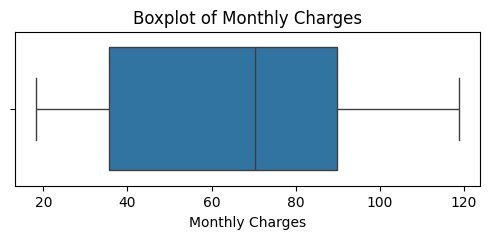

In [13]:
plt.figure(figsize=(6, 2))

sns.boxplot(x=df["MonthlyCharges"])

plt.title("Boxplot of Monthly Charges")
plt.xlabel("Monthly Charges")

plt.show()

### Observation: 
No significant extreme outliers are observed `MonthlyCharges`. 

# 4. EDA

### Business Objective:
Identify patterns and factors that influence customer churn in order to reduce customer loss.

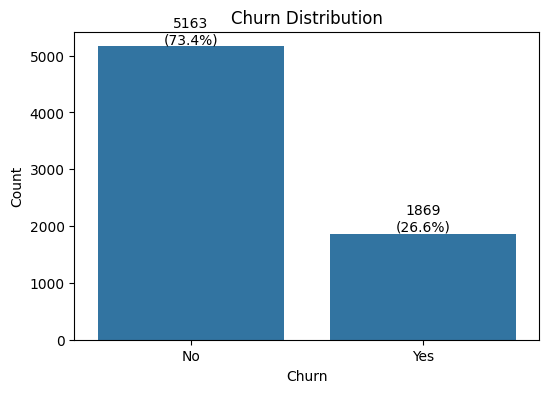

In [14]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(x='Churn', data=df)

# Add count and percentage labels
total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total
    ax.annotate(f'{count}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

### Observation:
The dataset shows class imbalance, where non-churn customers significantly outnumber churn customers. 

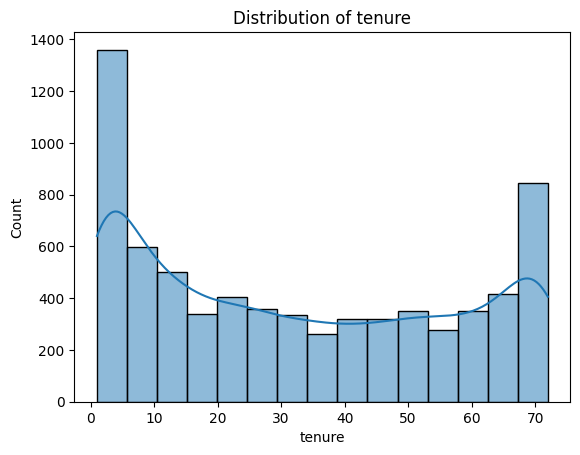

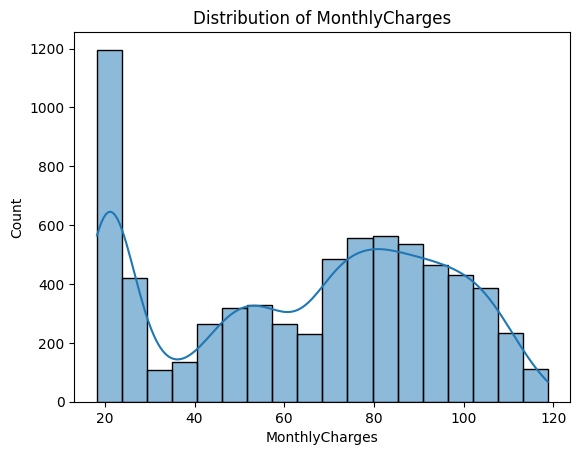

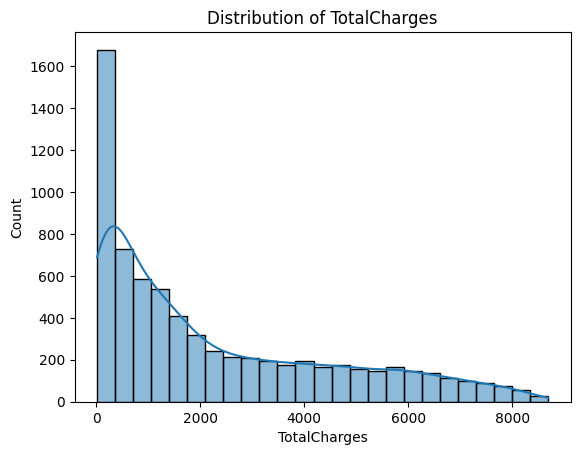

In [15]:
num_cols = ['tenure','MonthlyCharges','TotalCharges']

for col in num_cols:
    sns.histplot(df[col],kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

### Observation
- There are high number of both short and long tern customers
- Monthly charges are broadly distributed across different pricing plans, with no significant skewness or extreme outliers.
- `TotalCharges` is right-skewed, indicating that most customers have lower total charges.

Tenure vs Churn

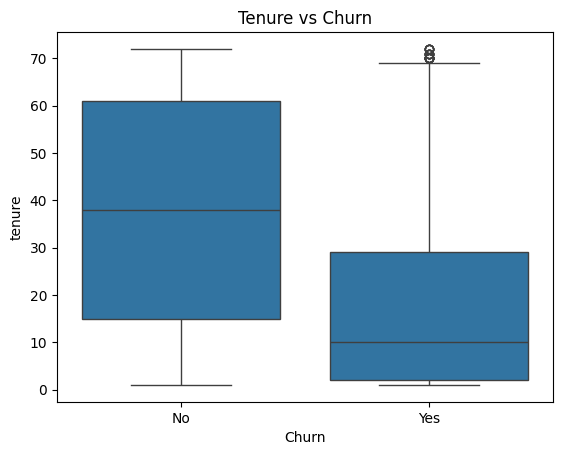

In [16]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

### Observation:
Customers with lower tenure are more likely to churn.

MonthlyCharge vs Churn

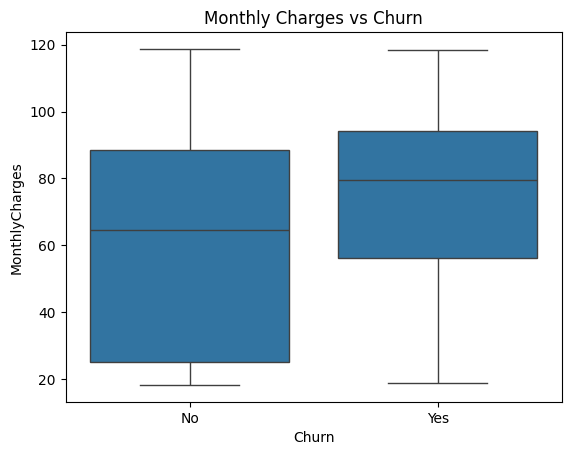

In [17]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

###  Observation
Customers who churn generally have higher monthly charges than those who do not churn.

Contract Type vs Churn

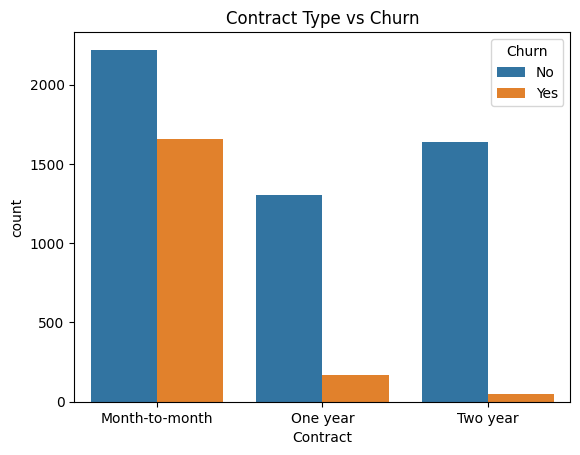

In [18]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.show()

### Observation
Month-to-month contracts show the highest churn ***
Long-term contracts reduce churn risk

Payment Method vs Churn

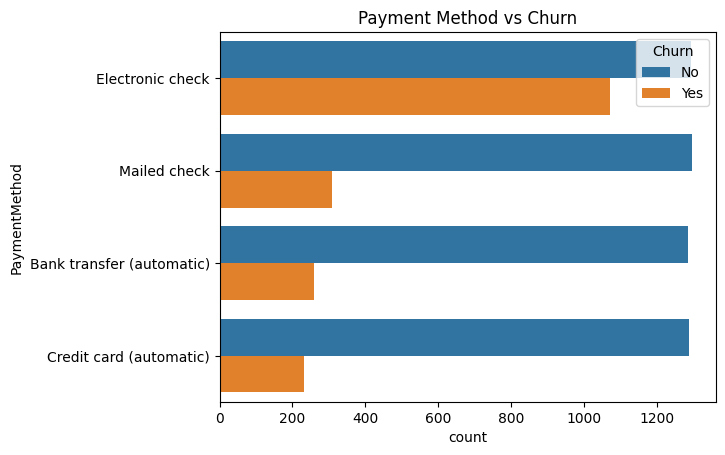

In [19]:
sns.countplot(y='PaymentMethod',hue='Churn',data=df)
plt.title("Payment Method vs Churn")
plt.show()

### Observation
- Electronic check users churn more
- Payment convenience impacts retention

Correlation Analysis

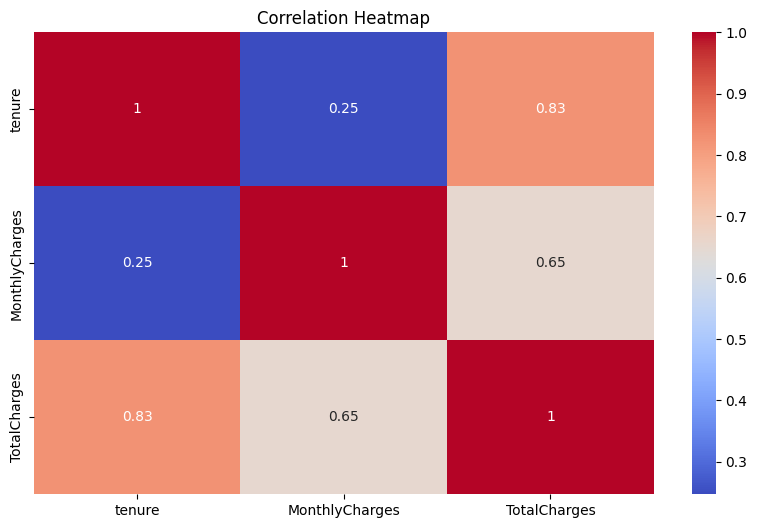

In [20]:
plt.figure(figsize=(10,6))

sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

### Observation
Tenure strongly correlates with TotalCharges,
MonthlyCharges weakly correlates with tenure

Conducted comprehensive exploratory data analysis to identify key churn drivers including tenure, contract type, monthly charges, and payment methods. Discovered that short-tenure customers on month-to-month contracts with higher charges have significantly higher churn risk, guiding feature engineering and model selection.

Retention strategies should prioritize short-tenure customers.

# 5. Feature Engineering

### Binary Encoding 

In [21]:
binary_cols = ['Partner', 'Dependents',
               'PhoneService',
               'PaperlessBilling',
               'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0})

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,Male,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


### One-Hot Encoding

In [22]:
# Select categorical columns
cat_cols = df.select_dtypes(
    include=['object', 'string']
).columns

# One-Hot Encoding
df = pd.get_dummies(df,
                    columns=cat_cols,
                    drop_first=True)

# Convert boolean columns to integers
bool_cols = df.select_dtypes(
    include='bool'
).columns

df[bool_cols] = df[bool_cols].astype(int)

df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,34,1,0,56.95,1889.50,0,1,...,0,0,0,0,0,1,0,0,0,1
2,0,0,0,2,1,1,53.85,108.15,1,1,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,45,0,0,42.30,1840.75,0,1,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,2,1,1,70.70,151.65,1,0,...,0,0,0,0,0,0,0,0,1,0


### Skewness Analysis

In [23]:
num_cols = ['tenure',
            'MonthlyCharges',
            'TotalCharges']

print(df[num_cols].skew())

# Log transformation on right-skewed feature
df['TotalCharges'] = np.log1p(df['TotalCharges'])

df.head()

tenure            0.237731
MonthlyCharges   -0.222103
TotalCharges      0.961642
dtype: float64


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,3.429137,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,34,1,0,56.95,7.544597,0,1,...,0,0,0,0,0,1,0,0,0,1
2,0,0,0,2,1,1,53.85,4.692723,1,1,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,45,0,0,42.30,7.518471,0,1,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,2,1,1,70.70,5.028148,1,0,...,0,0,0,0,0,0,0,0,1,0


Tenure group creation

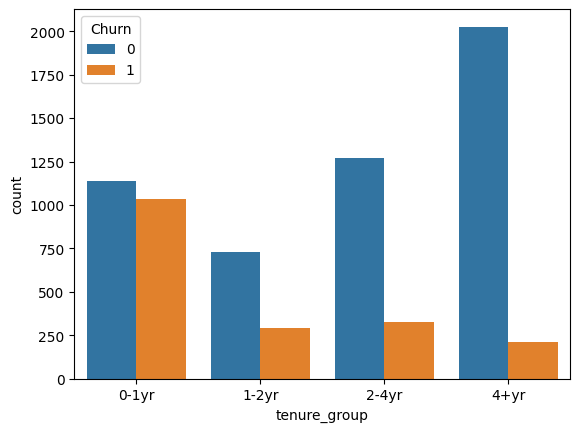

In [24]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,72],
                             labels=['0-1yr','1-2yr','2-4yr','4+yr'],
                             include_lowest=True)  
sns.countplot(x='tenure_group', hue='Churn', data=df)

plt.show()

Customers in the first year of subscription are more likely to churn.

In [25]:
df.drop('tenure_group', axis=1, inplace=True)

Categorical features were encoded, domain-driven features were created, and numerical features were prepared for machine learning modeling.

# 6. Modelling

Train-test split

In [26]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,          
    random_state=42,
    stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5625, 30)
X_test shape: (1407, 30)
y_train shape: (5625,)
y_test shape: (1407,)


The dataset was split into training and testing sets using an 80:20 ratio while preserving class distribution through stratification.

Feature scaling

In [27]:
scaler = StandardScaler()

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train.head() 
X_train.dtypes

SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                   float64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes                       int64
TechSupport_No internet service            int64
TechSupport_Yes     

## Logistic Regression

In [28]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

# Evaluation


print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("Confusion Matrix:\n",
      confusion_matrix(y_test, y_pred))

Accuracy: 0.7981520966595593
Precision: 0.643312101910828
Recall: 0.5401069518716578
F1 Score: 0.5872093023255814
Confusion Matrix:
 [[921 112]
 [172 202]]


### Observation:
The Logistic Regression model achieved an accuracy of approximately 80%. The model demonstrated strong overall performance, while achieving moderate recall in identifying churn customers.

## Random Forest

In [29]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,          
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7192608386638237
Precision: 0.4830917874396135
Recall: 0.8021390374331551
F1 Score: 0.6030150753768844
Confusion Matrix:
 [[712 321]
 [ 74 300]]


### Observation
The Random Forest model achieved significantly higher recall, enabling better identification of churn customers. Although overall accuracy decreased slightly, the model demonstrated stronger effectiveness in detecting at-risk customers, which is valuable for customer retention strategies.

Decision Tree

In [30]:
dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.7825159914712153
Precision: 0.60828025477707
Recall: 0.5106951871657754
F1 Score: 0.5552325581395349
Confusion Matrix:
 [[910 123]
 [183 191]]


### Observation:
The Decision Tree model achieved balanced classification performance but was outperformed by the tuned Random Forest model, particularly in identifying churn customers.

## XGBoost

In [31]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))

print("Confusion Matrix:\n",
      confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.7924662402274343
Precision: 0.6265432098765432
Recall: 0.5427807486631016
F1 Score: 0.5816618911174785
Confusion Matrix:
 [[912 121]
 [171 203]]


## 7. Hyperparameter tuning (on RF and XGBoost)

## Randomized Search on Random Forest

In [32]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced']
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

rf_random.best_params_

{'n_estimators': 500,
 'min_samples_split': 5,
 'min_samples_leaf': 4,
 'max_depth': 3,
 'class_weight': 'balanced'}

## Tuned Random Forest

In [33]:
best_rf = rf_random.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))

print("Precision:", precision_score(y_test, y_pred_rf_tuned))
print("Recall:", recall_score(y_test, y_pred_rf_tuned))
print("F1 Score:", f1_score(y_test, y_pred_rf_tuned))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_tuned))

Accuracy: 0.7078891257995735
Precision: 0.47131782945736433
Recall: 0.8128342245989305
F1 Score: 0.5966633954857704
Confusion Matrix:
 [[692 341]
 [ 70 304]]


## Randomized Search on XGBoost

In [34]:
xgb_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),

    param_distributions=xgb_param_grid,

    n_iter=20,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

xgb_random.fit(X_train, y_train)

xgb_random.best_params_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


{'subsample': 0.8,
 'n_estimators': 200,
 'max_depth': 3,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

## Tuned XGBoost

In [35]:
best_xgb = xgb_random.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb_tuned))
print("Precision:", precision_score(y_test, y_pred_xgb_tuned))
print("Recall:", recall_score(y_test, y_pred_xgb_tuned))
print("F1 Score:", f1_score(y_test, y_pred_xgb_tuned))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_tuned))

Accuracy: 0.7889125799573561
Precision: 0.6245954692556634
Recall: 0.516042780748663
F1 Score: 0.5651537335285505
Confusion Matrix:
 [[917 116]
 [181 193]]


## Model Comparison

| **Metric**    | **Logistic Regression** | **Decision Tree** | **Random Forest** | **XGBoost** | **Tuned Random Forest** | **Tuned XGBoost** |
| ------------- | ----------------------: | ----------------: | ----------------: | ----------: | ----------------------: | ----------------: |
| **Accuracy**  |                   0.798 |             0.783 |             0.719 |       0.792 |                   0.707 |             0.793 |
| **Precision** |                   0.643 |             0.608 |             0.483 |       0.627 |                   0.471 |             0.632 |
| **Recall**    |                   0.540 |             0.511 |             0.802 |       0.543 |                  **0.812**|             0.532 |
| **F1 Score**  |                   0.587 |             0.555 |             0.603 |       0.582 |                   0.596 |             0.578 |


The performance of multiple machine learning models was compared using Accuracy, Precision, Recall and F1-Score metrics to identify the most effective model for customer churn prediction.

## Conclusion
Hyperparameter tuning was performed to optimize model performance using recall as the primary evaluation metric. Although the tuned Random Forest showed a slight decrease in accuracy and precision, it achieved the highest recall, making it the most suitable model for identifying customers at risk of churn.

SMOTE was also applied to address class imbalance during model development. However, tuned Random Forest was retained as the final model, as it provided the best balance between recall and overall performance.

# 8. Important Features

                                 Feature  Importance
3                                 tenure    0.178207
26                     Contract_Two year    0.175101
11           InternetService_Fiber optic    0.096502
28        PaymentMethod_Electronic check    0.085665
7                           TotalCharges    0.081047
25                     Contract_One year    0.041399
17  DeviceProtection_No internet service    0.036175
14                    OnlineSecurity_Yes    0.033313
6                         MonthlyCharges    0.033061
21       StreamingTV_No internet service    0.032584


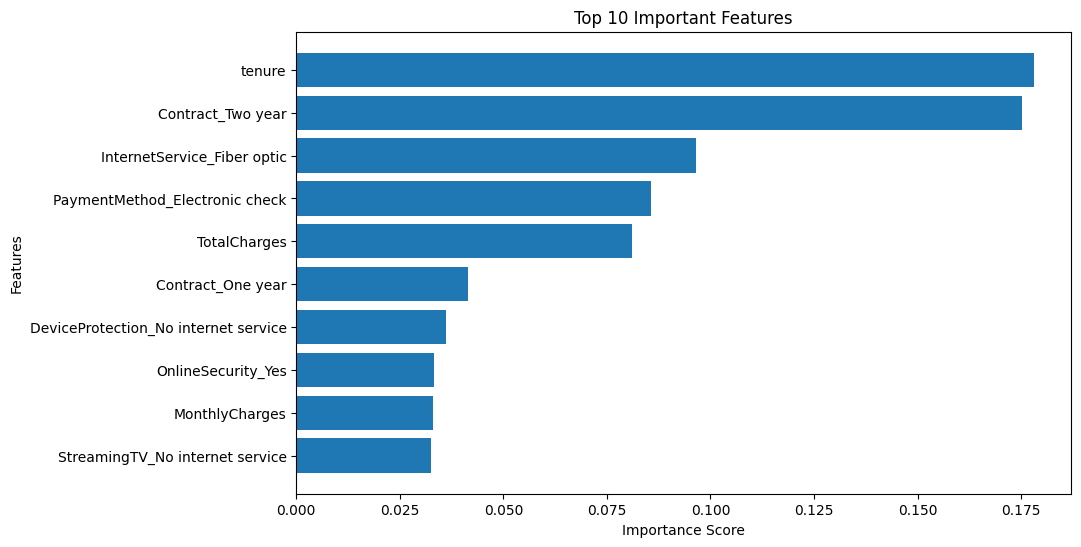

In [36]:
feature_importance = pd.DataFrame({

    'Feature': X_train.columns,

    'Importance': best_rf.feature_importances_
})

# Sort values
feature_importance = feature_importance.sort_values(
    
    by='Importance',
    
    ascending=False
)

# Top 10 Features
print(feature_importance.head(10))

plt.figure(figsize=(10,6))

plt.barh(

    feature_importance['Feature'].head(10),

    feature_importance['Importance'].head(10)
)

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

### Observation
The Tuned Random Forest model identified tenure, contract type, internet service, payment method, and billing-related features as the most influential factors in predicting customer churn.

# 9. SHAP

## Global SHAP Explainability

Background dataset has 5625 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5625 when initializing the masker.


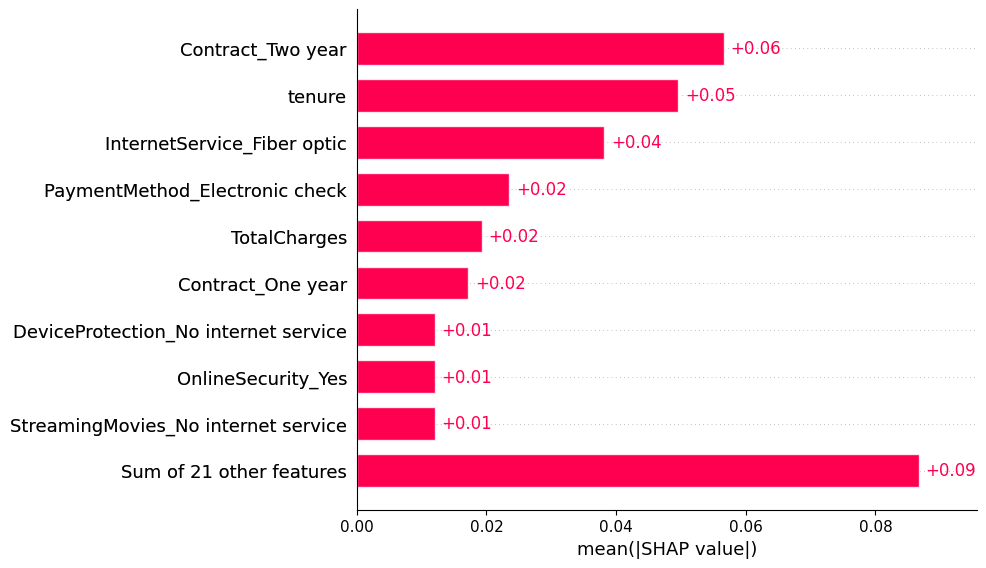

In [37]:
# Sample data for faster execution
X_sample = X_test.sample(300, random_state=42)

explainer = shap.Explainer(best_rf, X_train)

shap_values = explainer(X_sample)

shap.plots.bar(shap_values[:, :, 1], max_display=10)

### Observation:
SHAP analysis was performed to interpret the Tuned Random Forest model and understand the contribution of individual features toward customer churn prediction. Contract type, tenure, and internet service were the most influential features affecting churn predictions.

## Local SHAP Explainability

Customer Index: 5
Churn Probability: 0.6742048434000368


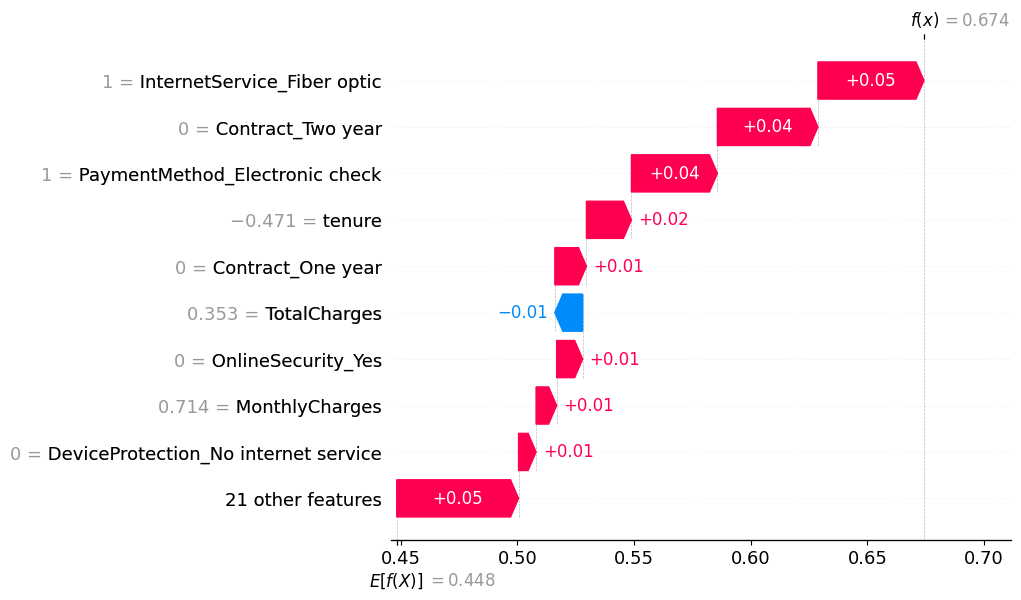

In [38]:
# Predict probabilities
pred_probs = best_rf.predict_proba(X_sample)[:, 1]

# Customer index
customer_index = 5

print("Customer Index:", customer_index)

print("Churn Probability:",
      pred_probs[customer_index])

# Local Explanation
shap.plots.waterfall(
    shap_values[customer_index, :, 1]
)

This plot explains how individual features contributed to the churn prediction of a specific customer.

## Why Recall is prioritized ?
In churn prediction, a false negative (missing a churner) can result in permanent loss of that customer and associated revenue. A false positive only wastes a small retention cost. Therefore, Recall is the primary optimization metric.

# Final Outcome

A machine learning pipeline was successfully developed to predict customer churn using classification algorithms such as Logistic Regression, Random Forest, Decision Tree, and XGBoost. Among all models, Tuned Random Forest was selected as the final model due to its high recall, making it well suited for identifying customers at risk of churning.

# 10. Save Model

In [39]:
joblib.dump(best_rf, "customer_churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']